# 🎓 Professor's Playground! — Final Model

## 0. Configuration — Edit paths here if needed

In [1]:
import os, pickle, zipfile, json, random

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_ROOT        = 'Data'
SUBFOLDER        = 'Preprocessed'
ZIP_PATH         = os.path.join(DATA_ROOT, f'{SUBFOLDER}.zip')   # Data/Preprocessed.zip
MODEL_PATH       = 'Model/model_final.pt'                        # saved .pt checkpoint
EXTRACT_DIR = DATA_ROOT                                          # Data/Preprocessed
OUTPUT_DIR       = 'Playground_outputs'                          # plots & reports
GOOGLE_DRIVE_URL = 'https://drive.google.com/file/d/1t8cSbhXX0I7g_mB9bPH5YFBAYIvhLCsC/view?usp=sharing'  
# ─────────────────────────────────────────────────────────────────────────────

## 1. Imports

In [2]:
import os, pickle, zipfile, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
    
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
)

# Reproducibility 
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        try:
            torch.mps.manual_seed(seed)
        except AttributeError:
            pass
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Device
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

if torch.backends.mps.is_available():
    try:
        torch.tensor([1.0], device="mps")
        device = torch.device("mps")
    except Exception as e:
        print(f"MPS not available: {e}, falling back to CPU")
        device = torch.device("cpu")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device : {device}")
print(f"Global seed  : {SEED}")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Outputs will be saved to: {OUTPUT_DIR}/")

Using device : cuda
Global seed  : 42
Outputs will be saved to: Playground_outputs/


## 2. Unzip Preprocessed Data

In [3]:
os.makedirs(DATA_ROOT, exist_ok=True)

if not os.path.exists(ZIP_PATH):
    if GOOGLE_DRIVE_URL.strip():
        print(f'Downloading dataset zip to {ZIP_PATH} from Google Drive ...')
        _download_from_google_drive(GOOGLE_DRIVE_URL.strip(), ZIP_PATH)
        print('Download complete.')
    else:
        raise FileNotFoundError(
            f'{ZIP_PATH} was not found. Place the zip there manually, or set GOOGLE_DRIVE_URL.'
        )

expected_folder = os.path.join(DATA_ROOT, SUBFOLDER)

if not os.path.exists(expected_folder):
    print(f'Extracting {ZIP_PATH} → {EXTRACT_DIR} ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print('Extraction complete.')
else:
    print(f'Data already extracted at {expected_folder} — skipping unzip.')

Data already extracted at Data\Preprocessed — skipping unzip.


## 3. Load Data & Metadata

In [4]:
def find_data_dir(base):
    """Auto-detect the directory containing train.csv (handles nested zip structures)."""
    for root, dirs, files in os.walk(base):
        if 'train.csv' in files:
            return root
    raise FileNotFoundError(f'Could not find train.csv under {base}')

DATA_DIR = find_data_dir(EXTRACT_DIR)
print(f'Data directory located at: {DATA_DIR}')

train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/val.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv')

with open(f'{DATA_DIR}/column_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

target      = metadata['target']
cat_cols    = [c for c in metadata['cat_cols']  if c in train_df.columns]
num_cols    = [c for c in metadata['num_cols']  if c in train_df.columns]
vocab_sizes = metadata['vocab_sizes']

print(f'Train      : {train_df.shape}')
print(f'Validation : {val_df.shape}')
print(f'Test       : {test_df.shape}')
print(f'Categorical features : {len(cat_cols)}')
print(f'Numerical features   : {len(num_cols)}')

Data directory located at: Data\Preprocessed
Train      : (472443, 469)
Validation : (29516, 469)
Test       : (88581, 469)
Categorical features : 41
Numerical features   : 427


## 4. Dataset & DataLoaders

In [5]:
class FraudDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cat_cols: list, num_cols: list, target: str) -> None:
        self.cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y   = torch.tensor(df[target].values,   dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int):
        return self.cat[idx], self.num[idx], self.y[idx]


BATCH_SIZE = 4096

val_ds  = FraudDataset(val_df,  cat_cols, num_cols, target)
test_ds = FraudDataset(test_df, cat_cols, num_cols, target)

use_pin_memory = (device.type == 'cuda')

val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=use_pin_memory)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=use_pin_memory)

print(f'Val  batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')

Val  batches: 8
Test batches: 22


## 5. Model Architecture

In [6]:
class FraudNet(nn.Module):
    def __init__(self, cat_cols: list, vocab_sizes: dict, num_dim: int, hidden_dim: int, dropout: float = 0.3) -> None:
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2))
            for col in cat_cols
        ])
        emb_dim   = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols)
        input_dim = emb_dim + num_dim

        h1 = hidden_dim
        h2 = h1 // 2
        h3 = max(h2 // 2, 32)

        def _block(in_f: int, out_f: int) -> nn.Sequential:
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.GELU(),
                nn.Dropout(p=dropout),
            )

        self.net = nn.Sequential(
            _block(input_dim, h1),
            _block(h1, h2),
            _block(h2, h3),
            nn.Linear(h3, 1),
        )

        self._xavier_init()

    def _xavier_init(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, cat: torch.Tensor, num: torch.Tensor) -> torch.Tensor:
        embs = [e(cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [num], dim=1)
        return self.net(x).squeeze(1)

    @torch.no_grad()
    def predict_proba(self, cat: torch.Tensor, num: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.forward(cat, num))

## 6. Load Saved Weights

In [7]:
checkpoint = torch.load(MODEL_PATH, map_location=device)

ckpt_cat_cols    = checkpoint['cat_cols']
ckpt_num_cols    = checkpoint['num_cols']
ckpt_vocab_sizes = checkpoint['vocab_sizes']
best_config      = checkpoint['config']

model = FraudNet(
    cat_cols=ckpt_cat_cols,
    vocab_sizes=ckpt_vocab_sizes,
    num_dim=len(ckpt_num_cols),
    hidden_dim=best_config['hidden_dim'],
    dropout=best_config['dropout'],
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

total_params = sum(p.numel() for p in model.parameters())

print(model)
print(f'\nTotal parameters : {total_params:,}')
print(f'\nBest hyperparameters from training:')
for k, v in best_config.items():
    print(f'  {k:20s}: {v}')

print(f'\nCheckpoint metrics saved during training:')
print(f'  Epoch      : {checkpoint["epoch"]}')
print(f'  Val PR-AUC : {checkpoint["val_pr_auc"]:.4f}')

C:\Users\65938\AppData\Local\Temp\ipykernel_25748\733641875.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=device)


FraudNet(
  (embeddings): ModuleList(
    (0): Embedding(6, 3)
    (1): Embedding(12819, 50)
    (2): Embedding(502, 50)
    (3): Embedding(115, 50)
    (4): Embedding(6, 3)
    (5): Embedding(116, 50)
    (6): Embedding(6, 3)
    (7): Embedding(307, 50)
    (8): Embedding(71, 36)
    (9): Embedding(61, 31)
    (10): Embedding(62, 31)
    (11-13): 3 x Embedding(4, 2)
    (14): Embedding(5, 3)
    (15-20): 6 x Embedding(4, 2)
    (21): Embedding(55, 28)
    (22): Embedding(26, 13)
    (23): Embedding(5, 3)
    (24): Embedding(4, 2)
    (25): Embedding(103, 50)
    (26): Embedding(517, 50)
    (27): Embedding(386, 50)
    (28-29): 2 x Embedding(4, 2)
    (30): Embedding(77, 39)
    (31): Embedding(128, 50)
    (32): Embedding(6, 3)
    (33): Embedding(233, 50)
    (34): Embedding(6, 3)
    (35-39): 5 x Embedding(4, 2)
    (40): Embedding(1680, 50)
  )
  (net): Sequential(
    (0): Sequential(
      (0): Linear(in_features=1210, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps

## 7. Inference

In [8]:
@torch.no_grad()
def get_predictions(model: nn.Module, loader: DataLoader, device: torch.device) -> tuple:
    model.eval()
    all_proba, all_y = [], []
    for cat, num, y in loader:
        cat, num = cat.to(device), num.to(device)
        proba = model.predict_proba(cat, num).cpu().numpy()
        all_proba.extend(proba)
        all_y.extend(y.numpy())
    return np.array(all_y), np.array(all_proba)


print('Running inference on validation set...')
val_y_true, val_proba = get_predictions(model, val_loader, device)

print('Running inference on test set...')
test_y_true, test_proba = get_predictions(model, test_loader, device)

print('Done.')

Running inference on validation set...
Running inference on test set...
Done.


## 8. Threshold Selection (F-β, β=2.0)

In [9]:
def find_best_fbeta_threshold(y_true: np.ndarray, y_proba: np.ndarray, beta: float = 2.0) -> tuple:
    """Select decision threshold on the validation set by maximising F-β."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    if len(thresholds) == 0:
        return 0.5, 0.0, 0.0, 0.0
    beta2 = beta ** 2
    scores = (
        (1 + beta2) * precision[:-1] * recall[:-1]
        / (beta2 * precision[:-1] + recall[:-1] + 1e-8)
    )
    best_idx = int(np.argmax(scores))
    return (
        float(thresholds[best_idx]),
        float(scores[best_idx]),
        float(recall[best_idx]),
        float(precision[best_idx]),
    )


BETA = 2.0  # weights recall twice as heavily as precision

# Threshold is selected ONLY on the validation set to avoid test-set leakage
best_thresh_recalc, val_fbeta, val_best_recall, val_best_precision = \
    find_best_fbeta_threshold(val_y_true, val_proba, beta=BETA)

print(f'Validation-selected threshold (F-β, β={BETA}): {best_thresh_recalc:.4f}')
print(f'  Val F-β    : {val_fbeta:.4f}')
print(f'  Val Recall : {val_best_recall:.4f}')
print(f'  Val Prec.  : {val_best_precision:.4f}')

Validation-selected threshold (F-β, β=2.0): 0.3072
  Val F-β    : 0.7983
  Val Recall : 0.8015
  Val Prec.  : 0.7856


## 9. Metrics

In [10]:
val_pr_auc  = average_precision_score(val_y_true,  val_proba)
test_pr_auc = average_precision_score(test_y_true, test_proba)

test_pred      = (test_proba >= best_thresh_recalc).astype(int)
test_recall    = recall_score(test_y_true,    test_pred, zero_division=0)
test_precision = precision_score(test_y_true, test_pred, zero_division=0)
test_f1        = f1_score(test_y_true,        test_pred, zero_division=0)

val_recall = recall_score(
    val_y_true, (val_proba >= best_thresh_recalc).astype(int), zero_division=0
)

print(f"{'='*55}")
print(f"  Results at threshold = {best_thresh_recalc:.4f}  (F-β, β={BETA})")
print(f"{'='*55}")
print(f"  Val  PR-AUC   : {val_pr_auc:.4f}")
print(f"  Test PR-AUC   : {test_pr_auc:.4f}")
print(f"  Val  F-β      : {val_fbeta:.4f}")
print(f"  Val  Recall   : {val_best_recall:.4f}")
print(f"  Val  Precision: {val_best_precision:.4f}")
print(f"  Test F1       : {test_f1:.4f}")
print(f"  Test Recall   : {test_recall:.4f}")
print(f"  Test Precision: {test_precision:.4f}")

final_metrics = {
    'best_config'              : best_config,
    'threshold_selection_beta' : BETA,
    'val_pr_auc'               : val_pr_auc,
    'test_pr_auc'              : test_pr_auc,
    'best_thresh'              : best_thresh_recalc,
    'val_fbeta'                : val_fbeta,
    'val_recall'               : val_recall,
    'val_precision'            : val_best_precision,
    'test_f1'                  : test_f1,
    'test_recall'              : test_recall,
    'test_precision'           : test_precision,
}
metrics_path = os.path.join(OUTPUT_DIR, 'final_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(final_metrics, f, indent=2)
print(f'\nMetrics saved to {metrics_path}')

  Results at threshold = 0.3072  (F-β, β=2.0)
  Val  PR-AUC   : 0.8423
  Test PR-AUC   : 0.8458
  Val  F-β      : 0.7983
  Val  Recall   : 0.8015
  Val  Precision: 0.7856
  Test F1       : 0.7893
  Test Recall   : 0.8032
  Test Precision: 0.7759

Metrics saved to Playground_outputs\final_metrics.json


## 10. Precision-Recall Curve

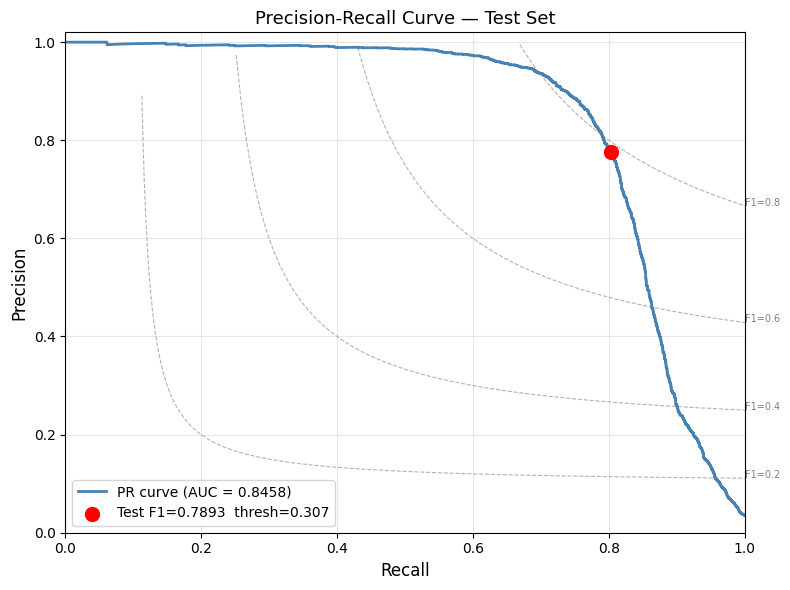

PR curve saved to Playground_outputs\pr_curve.png


In [11]:
precision_pts, recall_pts, _ = precision_recall_curve(test_y_true, test_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_pts, precision_pts, color='steelblue', lw=2,
        label=f'PR curve (AUC = {test_pr_auc:.4f})')
ax.scatter(test_recall, test_precision, color='red', zorder=5, s=100,
           label=f'Test F1={test_f1:.4f}  thresh={best_thresh_recalc:.3f}')

for f1_iso in [0.2, 0.4, 0.6, 0.8]:
    r_vals = np.linspace(0.01, 1.0, 300)
    p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
    mask   = (p_vals >= 0) & (p_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], '--', color='grey', lw=0.8, alpha=0.6)
    ax.annotate(f'F1={f1_iso}', xy=(r_vals[mask][-1], p_vals[mask][-1]),
                fontsize=7, color='grey')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Test Set', fontsize=13)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()

pr_path = os.path.join(OUTPUT_DIR, 'pr_curve.png')
plt.savefig(pr_path, dpi=150)
plt.show()
print(f'PR curve saved to {pr_path}')

## 11. Confusion Matrix

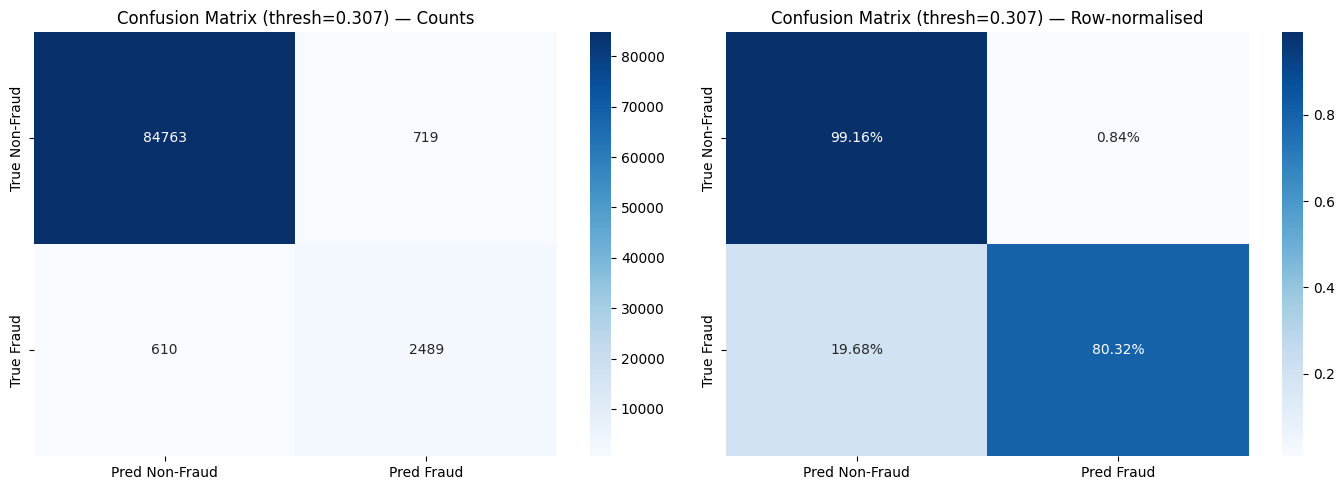


Classification Report (threshold=0.307):
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99     85482
       Fraud       0.78      0.80      0.79      3099

    accuracy                           0.98     88581
   macro avg       0.88      0.90      0.89     88581
weighted avg       0.99      0.98      0.99     88581

Confusion matrix saved to Playground_outputs\confusion_matrix.png
Classification report saved to Playground_outputs\classification_report.txt


In [12]:
cm     = confusion_matrix(test_y_true, test_pred)
labels = ['Non-Fraud', 'Fraud']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'Pred {l}' for l in labels],
            yticklabels=[f'True {l}' for l in labels])
axes[0].set_title(f'Confusion Matrix (thresh={best_thresh_recalc:.3f}) — Counts')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=[f'Pred {l}' for l in labels],
            yticklabels=[f'True {l}' for l in labels])
axes[1].set_title(f'Confusion Matrix (thresh={best_thresh_recalc:.3f}) — Row-normalised')

plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150)
plt.show()

print(f'\nClassification Report (threshold={best_thresh_recalc:.3f}):')
report = classification_report(test_y_true, test_pred, target_names=labels)
print(report)

report_path = os.path.join(OUTPUT_DIR, 'classification_report.txt')
with open(report_path, 'w') as f:
    f.write(f'Threshold: {best_thresh_recalc:.3f}\n\n{report}')

print(f'Confusion matrix saved to {cm_path}')
print(f'Classification report saved to {report_path}')

## 12. Summary

In [13]:
print(f"{'='*50}")
print(f"  All outputs saved to: {OUTPUT_DIR}/")
print(f"    pr_curve.png")
print(f"    confusion_matrix.png")
print(f"    classification_report.txt")
print(f"    final_metrics.json")
print(f"{'='*50}")

  All outputs saved to: Playground_outputs/
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    final_metrics.json
